In [18]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.ticker import LinearLocator, FormatStrFormatter
from matplotlib import cm


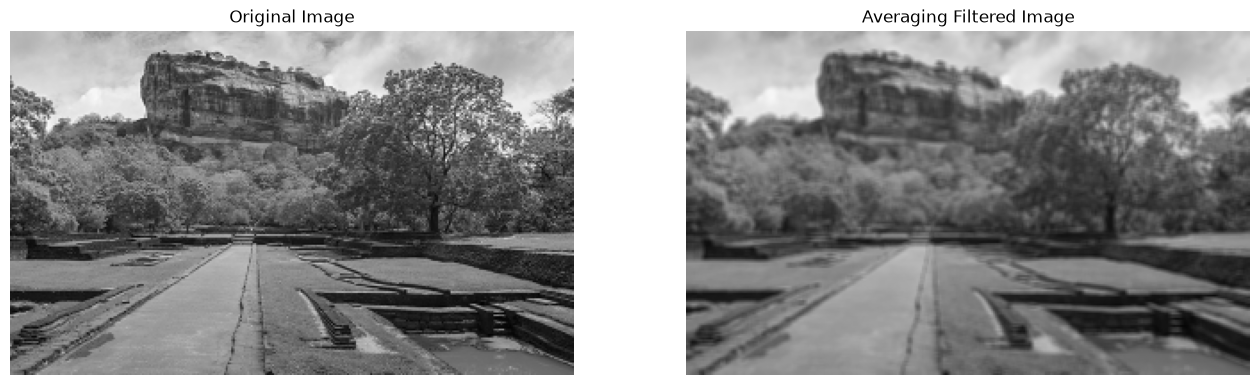

In [6]:

im = cv.imread('images/sigiriya.jpg', cv.IMREAD_REDUCED_GRAYSCALE_2)
assert im is not None

#Averaging filter
kernal = np.ones((3,3), np.float32)/9
im_avg = cv.filter2D(im, cv.CV_32F, kernal)

fig, ax = plt.subplots(1,2, figsize=(16,8))
ax[0].imshow(im, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original Image')
ax[1].imshow(im_avg, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Averaging Filtered Image')

for a in ax:
    a.axis('off')

plt.show()


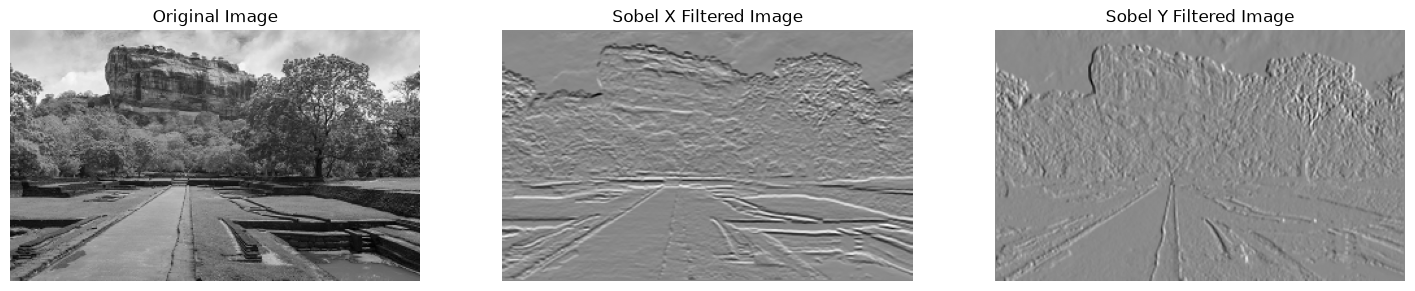

In [11]:
#Sobel filtering
sobel_x = np.array([[-1, -2, -1],[0, 0, 0],[1, 2, 1]])
sobel_y = np.array([[-1, 0, 1],[-2, 0, 2],[-1, 0, 1]])

im_sobel_x = cv.filter2D(im, cv.CV_64F, sobel_x)
im_sobel_y = cv.filter2D(im, cv.CV_64F, sobel_y)

im_sobel_x = cv.normalize(im_sobel_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
im_sobel_y = cv.normalize(im_sobel_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1,3, figsize=(18,6))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')
ax[1].imshow(im_sobel_x, cmap='gray')
ax[1].set_title('Sobel X Filtered Image')
ax[2].imshow(im_sobel_y, cmap='gray')
ax[2].set_title('Sobel Y Filtered Image')

for a in ax:
    a.axis('off')

plt.show()



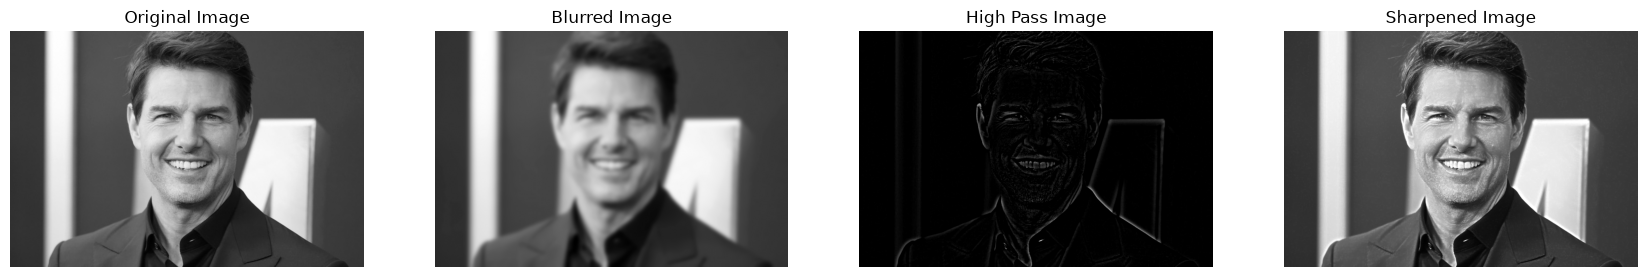

In [14]:
#Sharpening the image

im = cv.imread('images/tom.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

#Blurring the image to get a low pass filtered image
im_blurred = cv.GaussianBlur(im, (21, 21), 0)

#High pass image 
im_hp = cv.subtract(im, im_blurred)

#Sharpened image
im_sharp = cv.addWeighted(im, 1.0, im_hp, 1.5, 0)

fig, ax = plt.subplots(1,4, figsize=(21,10))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')
ax[3].imshow(im_sharp, cmap='gray')
ax[3].set_title('Sharpened Image')
ax[1].imshow(im_blurred, cmap='gray')
ax[1].set_title('Blurred Image')
ax[2].imshow(im_hp, cmap='gray')
ax[2].set_title('High Pass Image')

for a in ax:
    a.axis('off')

plt.show()



$\Large Gaussian\ Kernal$\
$G_\sigma(x,y) = \frac{1}{2\pi\sigma^2}e^{-\frac{x^2+y^2}{2\sigma^2}}$

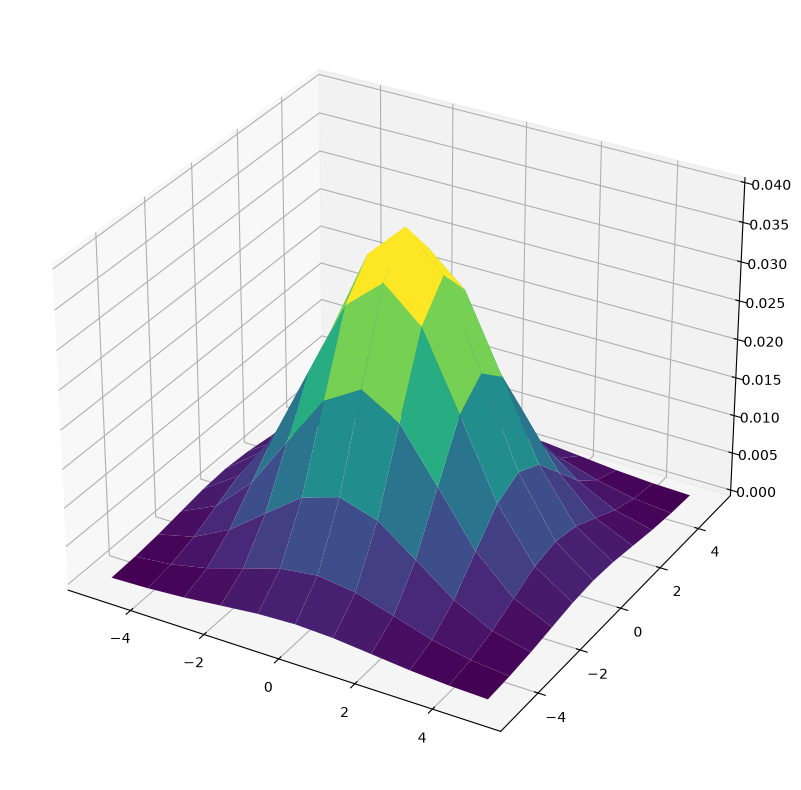

In [52]:
#Gaussian filter
sigma = 2.0
x = np.arange(-5, 5.1, 1)
y = np.arange(-5, 5.1, 1)
x, y = np.meshgrid(x, y)

g_xy = (1/(2*np.pi*sigma**2)) * np.exp(-(x**2 + y**2)/(2*sigma**2))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(x, y, g_xy, cmap='viridis')

plt.show()




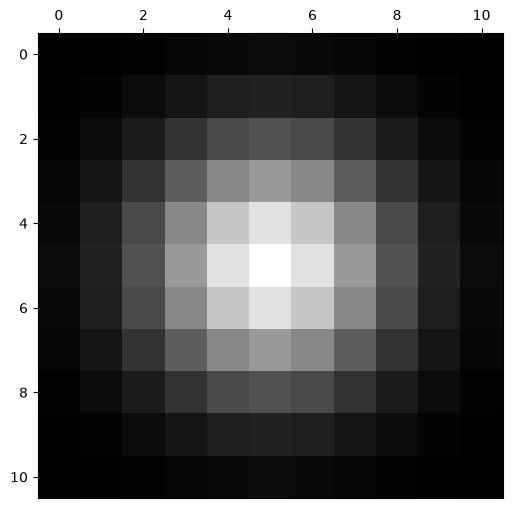

In [53]:
#2D plot
fig2, ax2= plt.subplots(1, 1, figsize = (6,8))
g_xy = cv.normalize(g_xy, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
ax2.imshow(g_xy, cmap= 'gray')
ax2.xaxis.set_ticks_position('top')
plt.show()

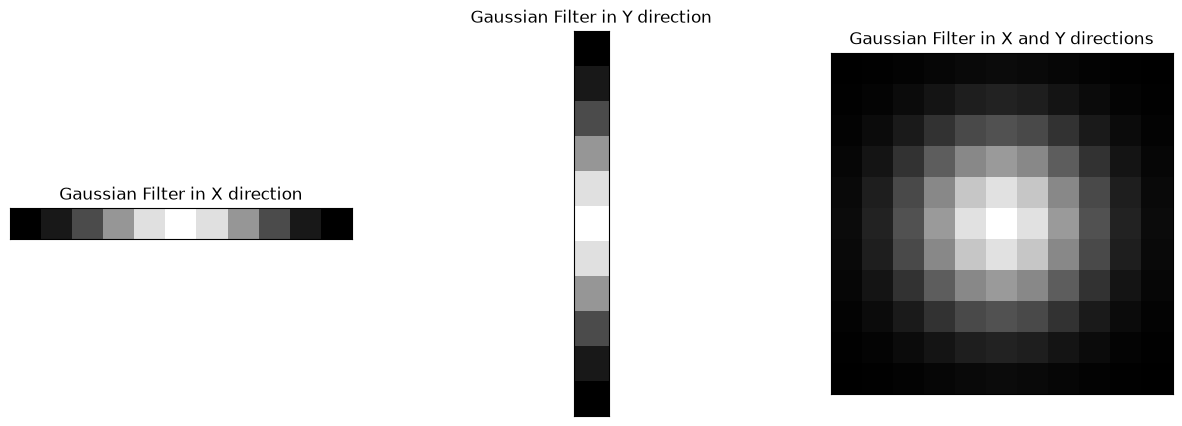

In [66]:
# Gaussian functions in x and y directions
g_x = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-(x**2)/(2*sigma**2))
g_y = (1/(np.sqrt(2*np.pi)*sigma)) * np.exp(-(y**2)/(2*sigma**2))

# 2D Gaussian from outer product
g_xy_2d = np.outer(g_y, g_x)

# Normalizing the Gaussian functions to the range [0, 255]
g_x_norm = cv.normalize(g_x, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
g_y_norm = cv.normalize(g_y, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
g_xy_2d_norm = cv.normalize(g_xy_2d, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig3, ax3 = plt.subplots(1, 3, figsize=(15, 5))

ax3[0].imshow(g_x_norm.reshape(1, -1), cmap='gray')
ax3[0].set_title('Gaussian Filter in X direction')

ax3[1].imshow(g_y_norm.reshape(-1, 1), cmap='gray')
ax3[1].set_title('Gaussian Filter in Y direction')

ax3[2].imshow(g_xy_2d_norm, cmap='gray')
ax3[2].set_title('Gaussian Filter in X and Y directions')

for a in ax3:
    a.set_xticks([])
    a.set_yticks([])

plt.show()

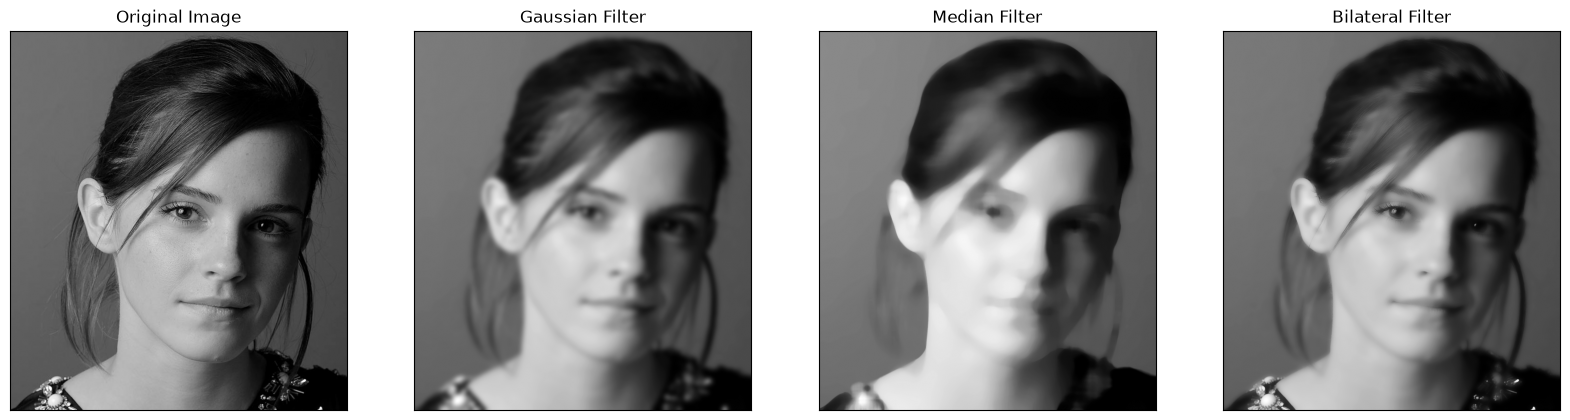

In [80]:
im = cv.imread('images/emma.jpg', cv.IMREAD_GRAYSCALE)
assert im is not None

#Kernal size
k = 31

#Gaussian filter
img_gaussian = cv.GaussianBlur(im, (k, k), 0)

#Median filter
img_median = cv.medianBlur(im, k)

#Bilateral filter
img_bilateral = cv.bilateralFilter(im, k, 75, 5)

#Normalizing the filtered images to the range [0, 255]
img_gaussian = cv.normalize(img_gaussian, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)
img_median = cv.normalize(img_median, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)   
img_bilateral = cv.normalize(img_bilateral, None, 0, 255, cv.NORM_MINMAX, cv.CV_8U)

fig, ax = plt.subplots(1, 4, figsize=(20, 10))
ax[0].imshow(im, cmap='gray')
ax[0].set_title('Original Image')

ax[1].imshow(img_gaussian, cmap='gray')
ax[1].set_title('Gaussian Filter')

ax[2].imshow(img_median, cmap='gray')
ax[2].set_title('Median Filter')

ax[3].imshow(img_bilateral, cmap='gray')
ax[3].set_title('Bilateral Filter')

for a in ax:
    a.set_xticks([])
    a.set_yticks([])

plt.show()
